# Notebook 2: Dataset Loader
This notebook:
1. Crops person images from PRW scene frames using `.mat` annotations
2. Saves cropped images organised by identity
3. Prepares the CCTV 1K dataset into query/gallery splits
4. Creates PyTorch DataLoaders for training and evaluation

In [3]:
import os
import json
import shutil
import random
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ── PATHS ─────────────────────────────────────────────────────────
PRW_ROOT   = r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\PRW'
CCTV_ROOT  = r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\pedestrian_1k'
CROPS_DIR  = r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\PRW_crops'
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Libraries loaded!')

Libraries loaded!


In [4]:
import os
import scipy.io

PRW_ROOT    = r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\PRW'
PRW_FRAMES  = os.path.join(PRW_ROOT, 'frames')
PRW_ANNO    = os.path.join(PRW_ROOT, 'annotations')

# Check 1: What do actual frame filenames look like?
actual_frames = os.listdir(PRW_FRAMES)[:5]
print("Actual frame filenames:")
for f in actual_frames:
    print(f"  '{f}'")

# Check 2: What do annotation filenames look like?
actual_annos = os.listdir(PRW_ANNO)[:5]
print("\nActual annotation filenames:")
for f in actual_annos:
    print(f"  '{f}'")

# Check 3: What does frame_train.mat say?
frame_train = scipy.io.loadmat(os.path.join(PRW_ROOT, 'frame_train.mat'))
print("\nKeys in frame_train.mat:", [k for k in frame_train.keys() if not k.startswith('_')])

# Check 4: What is the actual structure of the frame list?
key = [k for k in frame_train.keys() if not k.startswith('_')][0]
print(f"\nKey used: '{key}'")
print("Type:", type(frame_train[key]))
print("Shape:", frame_train[key].shape)
print("Sample raw entry:", frame_train[key][0])

Actual frame filenames:
  'c1s1_000151.jpg'
  'c1s1_000376.jpg'
  'c1s1_000401.jpg'
  'c1s1_000426.jpg'
  'c1s1_000451.jpg'

Actual annotation filenames:
  'c1s1_000151.jpg.mat'
  'c1s1_000376.jpg.mat'
  'c1s1_000401.jpg.mat'
  'c1s1_000426.jpg.mat'
  'c1s1_000451.jpg.mat'

Keys in frame_train.mat: ['img_index_train']

Key used: 'img_index_train'
Type: <class 'numpy.ndarray'>
Shape: (5704, 1)
Sample raw entry: [array(['c1s1_000151'], dtype='<U11')]


## Step 1: Crop Person Images from PRW Frames

In [5]:
import os
import scipy.io
import numpy as np
from PIL import Image
from tqdm import tqdm

def crop_persons_from_prw(prw_root, output_dir, min_size=32):
    frames_dir = os.path.join(prw_root, 'frames')
    anno_dir   = os.path.join(prw_root, 'annotations')
    os.makedirs(output_dir, exist_ok=True)

    # ✅ Fix 1: correctly parse nested array structure
    frame_train = scipy.io.loadmat(os.path.join(prw_root, 'frame_train.mat'))
    train_frames = set(
        str(entry[0][0]) for entry in frame_train['img_index_train']
    )
    print(f"Training frames loaded: {len(train_frames)}")
    print(f"Sample frame name: {list(train_frames)[:2]}")

    saved, skipped = 0, 0
    # ✅ Fix 2: annotation files end in .jpg.mat not .mat
    anno_files = [f for f in os.listdir(anno_dir) if f.endswith('.jpg.mat')]
    print(f"Annotation files found: {len(anno_files)}")

    for anno_file in tqdm(anno_files, desc='Cropping PRW persons'):
        # ✅ Fix 3: strip .jpg.mat to get frame name
        frame_name = anno_file.replace('.jpg.mat', '')

        # Only process training frames
        if frame_name not in train_frames:
            continue

        anno_path = os.path.join(anno_dir, anno_file)
        anno = scipy.io.loadmat(anno_path)

        if 'box_new' not in anno:
            continue

        # ✅ Fix 4: frame images are named c1s1_000151.jpg
        img_path = os.path.join(frames_dir, frame_name + '.jpg')
        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert('RGB')
        W, H = img.size
        boxes = anno['box_new']

        for idx, box in enumerate(boxes):
            pid = int(box[0])
            x   = int(box[1])
            y   = int(box[2])
            w   = int(box[3])
            h   = int(box[4])

            # Skip unlabelled (pid <= 0) and tiny boxes
            if pid <= 0 or w < min_size or h < min_size:
                skipped += 1
                continue

            # Clamp to image boundaries
            x1 = max(0, x)
            y1 = max(0, y)
            x2 = min(W, x + w)
            y2 = min(H, y + h)

            crop = img.crop((x1, y1, x2, y2))

            pid_dir   = os.path.join(output_dir, f'{pid:04d}')
            os.makedirs(pid_dir, exist_ok=True)
            save_name = f'{frame_name}_crop{idx:02d}.jpg'
            crop.save(os.path.join(pid_dir, save_name))
            saved += 1

    print(f'\n✅ Done! Saved: {saved} crops | Skipped: {skipped}')
    print(f'Total identities with crops: {len(os.listdir(output_dir))}')
    return output_dir

# Run it
crop_persons_from_prw(PRW_ROOT, CROPS_DIR)
# ```

# Run this and you should see something like:
# ```
# Training frames loaded: 5704
# Annotation files found: 11816
# ✅ Done! Saved: ~17000 crops | Skipped: ~XXXX
# Total identities with crops: ~480

Training frames loaded: 5704
Sample frame name: ['c3s1_081292', 'c6s1_047501']
Annotation files found: 11816


Cropping PRW persons: 100%|██████████| 11816/11816 [04:43<00:00, 41.66it/s] 


✅ Done! Saved: 14718 crops | Skipped: 3313
Total identities with crops: 483


'D:\\MTech\\Sem-2\\IT585-Advanced_ML\\AML-project\\data\\PRW_crops'

Total identities cropped: 483


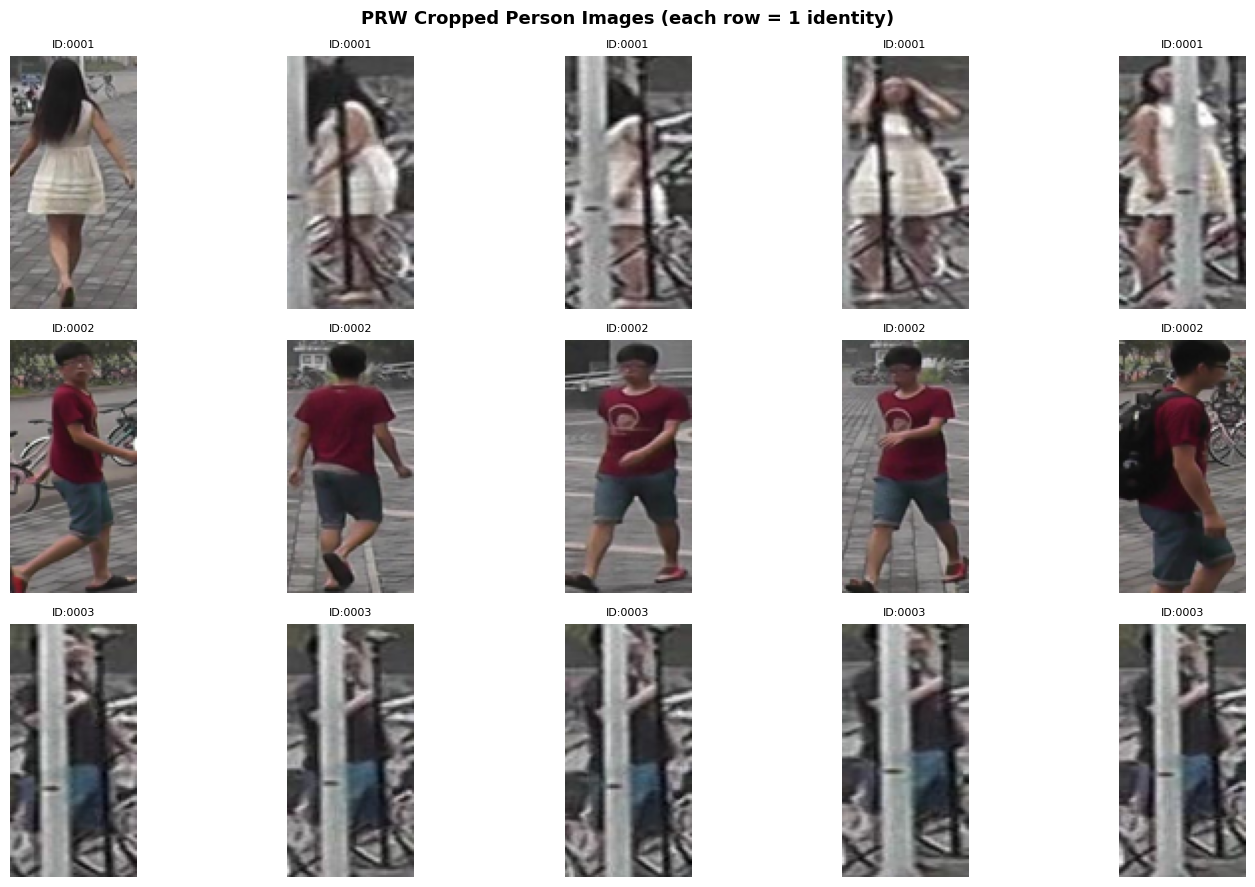

In [6]:
# Verify and visualise some crops
all_pids = sorted(os.listdir(CROPS_DIR))
print(f'Total identities cropped: {len(all_pids)}')

# Show sample crops for 3 identities
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('PRW Cropped Person Images (each row = 1 identity)', 
             fontsize=13, fontweight='bold')

for row, pid in enumerate(all_pids[:3]):
    pid_dir = os.path.join(CROPS_DIR, pid)
    crops   = os.listdir(pid_dir)[:5]
    for col in range(5):
        ax = axes[row][col]
        if col < len(crops):
            img = Image.open(os.path.join(pid_dir, crops[col])).resize((64, 128))
            ax.imshow(img)
            ax.set_title(f'ID:{pid}', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Filter PRW Identities (Keep Those With Enough Samples)

In [7]:
MIN_SAMPLES_PER_ID = 4  # need at least 4 images per identity for triplet loss

valid_pids = []
for pid in os.listdir(CROPS_DIR):
    n = len(os.listdir(os.path.join(CROPS_DIR, pid)))
    if n >= MIN_SAMPLES_PER_ID:
        valid_pids.append(pid)

print(f'Identities with >= {MIN_SAMPLES_PER_ID} images: {len(valid_pids)}')

# Build label map: folder name → integer label (0, 1, 2, ...)
valid_pids = sorted(valid_pids)
pid_to_label = {pid: idx for idx, pid in enumerate(valid_pids)}

# Collect all (image_path, label) pairs
all_train_samples = []
for pid in valid_pids:
    pid_dir = os.path.join(CROPS_DIR, pid)
    for img_name in os.listdir(pid_dir):
        img_path = os.path.join(pid_dir, img_name)
        all_train_samples.append((img_path, pid_to_label[pid]))

random.shuffle(all_train_samples)
print(f'Total training samples : {len(all_train_samples)}')
print(f'Total identities       : {len(valid_pids)}')

Identities with >= 4 images: 465
Total training samples : 14676
Total identities       : 465


## Step 3: Prepare CCTV 1K Query/Gallery Splits

In [8]:
# Parse all CCTV images grouped by identity
all_cctv_images = sorted([
    f for f in os.listdir(CCTV_ROOT)
    if f.endswith('.png') and f.startswith('ped_')
])

cctv_by_id = defaultdict(list)
for img in all_cctv_images:
    pid = int(img.split('_')[1])
    cctv_by_id[pid].append(img)

# For each identity: 1 image → query, rest → gallery
query_samples   = []  # (img_path, pid, cam_id)
gallery_samples = []

for pid, imgs in cctv_by_id.items():
    if len(imgs) < 2:
        continue  # need at least 2 images
    random.shuffle(imgs)
    # First image → query
    query_samples.append((
        os.path.join(CCTV_ROOT, imgs[0]), pid, 0
    ))
    # Rest → gallery
    for img in imgs[1:]:
        gallery_samples.append((
            os.path.join(CCTV_ROOT, img), pid, 1
        ))

print(f'CCTV 1K — Query samples   : {len(query_samples)}')
print(f'CCTV 1K — Gallery samples : {len(gallery_samples)}')
print(f'CCTV 1K — Total identities: {len(cctv_by_id)}')

CCTV 1K — Query samples   : 200
CCTV 1K — Gallery samples : 799
CCTV 1K — Total identities: 200


## Step 4: Define PyTorch Dataset Classes

In [9]:
# Image transforms
TRAIN_TRANSFORM = T.Compose([
    T.Resize((256, 128)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

TEST_TRANSFORM = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])


class PRWTrainDataset(Dataset):
    """PRW cropped person images for training."""
    def __init__(self, samples, transform=None):
        self.samples   = samples   # list of (img_path, label)
        self.transform = transform
        self.num_classes = len(set(s[1] for s in samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


class CCTVTestDataset(Dataset):
    """CCTV 1K pedestrian images for query/gallery evaluation."""
    def __init__(self, samples, transform=None):
        # samples: list of (img_path, pid, cam_id)
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, pid, cam_id = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, pid, cam_id


print('Dataset classes defined!')

Dataset classes defined!


In [10]:
# Create Dataset objects
train_dataset   = PRWTrainDataset(all_train_samples, transform=TRAIN_TRANSFORM)
query_dataset   = CCTVTestDataset(query_samples,     transform=TEST_TRANSFORM)
gallery_dataset = CCTVTestDataset(gallery_samples,   transform=TEST_TRANSFORM)

# Create DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0   # keep 0 on Windows to avoid multiprocessing issues

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, 
                            shuffle=True,  num_workers=NUM_WORKERS)
query_loader   = DataLoader(query_dataset,   batch_size=BATCH_SIZE, 
                            shuffle=False, num_workers=NUM_WORKERS)
gallery_loader = DataLoader(gallery_dataset, batch_size=BATCH_SIZE, 
                            shuffle=False, num_workers=NUM_WORKERS)

print('DataLoaders ready!')
print(f'  Train batches   : {len(train_loader)}')
print(f'  Query batches   : {len(query_loader)}')
print(f'  Gallery batches : {len(gallery_loader)}')

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f'\nSample train batch — images: {imgs.shape}, labels: {labels.shape}')

imgs, pids, cams = next(iter(query_loader))
print(f'Sample query batch — images: {imgs.shape}, pids: {pids[:5].tolist()}')

DataLoaders ready!
  Train batches   : 459
  Query batches   : 7
  Gallery batches : 25

Sample train batch — images: torch.Size([32, 3, 256, 128]), labels: torch.Size([32])
Sample query batch — images: torch.Size([32, 3, 256, 128]), pids: [100, 101, 102, 103, 104]


In [11]:
# Save important variables for use in later notebooks
import pickle
save_data = {
    'all_train_samples' : all_train_samples,
    'query_samples'     : query_samples,
    'gallery_samples'   : gallery_samples,
    'pid_to_label'      : pid_to_label,
    'num_classes'       : len(valid_pids),
    'PRW_ROOT'          : PRW_ROOT,
    'CCTV_ROOT'         : CCTV_ROOT,
    'CROPS_DIR'         : CROPS_DIR,
}
with open('dataset_info.pkl', 'wb') as f:
    pickle.dump(save_data, f)
print('✅ Dataset info saved to dataset_info.pkl')
print('\n✅ Ready for Notebook 3: Model Definition')

✅ Dataset info saved to dataset_info.pkl

✅ Ready for Notebook 3: Model Definition
